# Simulated verificaition of dynamics on STANCE PHASE


In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.io
import pandas as pd

In [2]:
# Loading the data

sim_data = pd.read_csv("data/stance_exp_data.csv")
t_sim = sim_data['time'].to_numpy()
theta1_sim = sim_data['theta1'].to_numpy()
theta2_sim = sim_data['theta2'].to_numpy()

t_theo = scipy.io.loadmat("data/matlab_theo/t.mat")['t'].flatten()
theta1_theo = scipy.io.loadmat("data/matlab_theo/theta_1.mat")['theta_1'].flatten()
theta2_theo = scipy.io.loadmat("data/matlab_theo/theta_2.mat")['theta_2'].flatten()

In [3]:
# Calculate the Error
t_interp = np.linspace(0, 10, 1000)
theta1_sim_interp = np.interp(t_interp, t_sim, theta1_sim)
theta2_sim_interp = np.interp(t_interp, t_sim, theta2_sim)
theta1_theo_interp = np.interp(t_interp, t_theo, theta1_theo)
theta2_theo_interp = np.interp(t_interp, t_theo, theta2_theo)

rmse_theta1 = np.sqrt(np.mean(np.square(theta1_sim_interp-theta1_theo_interp)))
rmse_theta2 = np.sqrt(np.mean(np.square(theta2_sim_interp-theta2_theo_interp)))
mae_theta1 = np.mean(np.abs(theta1_sim_interp-theta1_theo_interp))
mae_theta2 = np.mean(np.abs(theta2_sim_interp-theta2_theo_interp))
maxerror_theta1 = np.max(np.abs(theta1_sim_interp-theta1_theo_interp))
maxerror_theta2 = np.max(np.abs(theta2_sim_interp-theta2_theo_interp))

# Save to csv file
error_data = pd.DataFrame({
    'rmse_theta1': [rmse_theta1],
    'rmse_theta2': [rmse_theta2],
    'mae_theta1': [mae_theta1],
    'mae_theta2': [mae_theta2],
    'maxerror_theta1': [maxerror_theta1],
    'maxerror_theta2': [maxerror_theta2]
})
error_data.to_csv('data/stance_error_summary.csv', index=False, float_format='%.6f')
error_data

,rmse_theta1,rmse_theta2,mae_theta1,mae_theta2,maxerror_theta1,maxerror_theta2
0,0.016757,0.026163,0.014558,0.024646,0.040061,0.058295


In [42]:
# Draw the step response of Stance Phase
from matplotlib import rcParams

rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12+2,                # 默认字体大小（一般用于轴标签）
    "axes.titlesize": 14+2,          # 图标题
    "axes.labelsize": 12+2,          # 坐标轴标签
    "xtick.labelsize": 10+2,         # x轴刻度字体
    "ytick.labelsize": 10+2,         # y轴刻度字体
    "legend.fontsize": 10+2,         # 图例字体
    "figure.titlesize": 14+2,        # 整体图标题（如果用 plt.suptitle）
})
#     "axes.unicode_minus": False,  # Solve the problem of negative sign not displaying
#     "font.size": 40,  # Set font size
#     "axes.titlesize": 35,  # Set title font size
#     "axes.labelsize": 35,  # Set axis label font size
#     "xtick.labelsize": 30,  # Set x-axis tick font size
#     "ytick.labelsize": 30,  # Set y-axis tick font size
# }

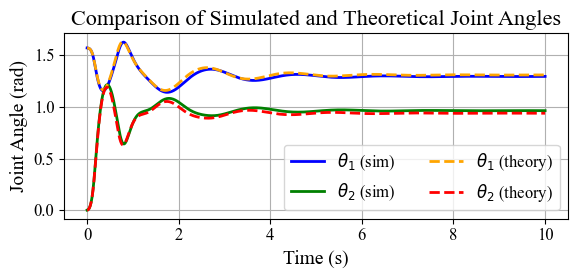

In [48]:
plt.figure(figsize=(6, 3))

# Plot θ1
plt.plot(t_interp, theta1_sim_interp, label=r'$\theta_1$ (sim)', color='blue', linewidth=2, linestyle='-')

# Plot θ2
plt.plot(t_interp, theta2_sim_interp, label=r'$\theta_2$ (sim)', color='green', linewidth=2, linestyle='-')

plt.plot(t_interp, theta1_theo_interp, label=r'$\theta_1$ (theory)', color='orange', linewidth=2, linestyle='--')

plt.plot(t_interp, theta2_theo_interp, label=r'$\theta_2$ (theory)', color='red', linewidth=2, linestyle='--')

# Titles and labels
plt.title("Comparison of Simulated and Theoretical Joint Angles", fontsize=16)
plt.xlabel("Time (s)")
plt.ylabel("Joint Angle (rad)")

# Legend, grid, layout
plt.legend(ncol=2, loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig('figure/stance_phase_new.png', dpi=200, bbox_inches='tight')

plt.show()

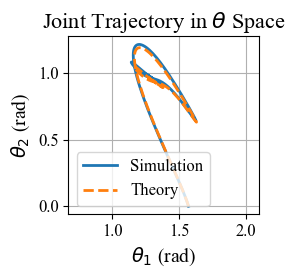

In [47]:
plt.figure(figsize=(3, 3))
# --- Top right: Trajectory plot ---
plt.plot(theta1_sim_interp, theta2_sim_interp, zorder=3, linewidth=2, linestyle='-', label='Simulation')  # Line
plt.plot(theta1_theo_interp, theta2_theo_interp, zorder=3, linewidth=2, linestyle='--', label='Theory')  # Line

plt.xlabel(r'$\theta_1$ (rad)')
plt.ylabel(r'$\theta_2$ (rad)')
plt.title(r'Joint Trajectory in $\theta$ Space', fontsize=16)
plt.axis('equal')
# plt.axis([1.1-0.7, 1.1+0.7, -0.1, 1.3])
plt.grid(True)

# plt.gca().set_aspect('equal', adjustable='box')  # ✅ 关键代码

plt.tight_layout()
plt.legend()

plt.savefig('./figure/stance_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

legendSet = {
    'loc': 'upper right',
    'fontsize': 30,
}

fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=200, constrained_layout=True)  # Two rows and two columns layout

# --- Top left: Time curve ---
axs[0, 0].plot(t_interp, theta2_sim_interp)
axs[0, 0].plot(t_interp, theta2_theo_interp)
axs[0, 0].set_xlabel('time (s)')
axs[0, 0].set_ylabel(r'$\theta_2$ (rad)')
axs[0, 0].set_title(r'$\theta_2$ vs Time')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

# Mark start and end points
axs[0, 0].scatter(t_interp[0], theta2_sim_interp[0], s=300, color='purple', marker='*', alpha=0.9, zorder=5)
axs[0, 0].scatter(t_interp[-1], theta2_sim_interp[-1], s=300, color='red', marker='*', alpha=0.9, zorder=5)

edge = math.pi/6 * 0
axs[0, 0].set_ylim([0, math.pi/2])
axs[0, 0].set_xlim([-0.5, 10.5])

axs[0, 0].set_xticks(np.arange(0, 10.5, 5))
axs[0, 0].set_xticklabels([f'{round(i, 0)}' for i in np.arange(0, 10.5, 5)])
axs[0, 0].set_yticks(np.arange(0, math.pi/2+edge, 0.5))
axs[0, 0].set_yticklabels([f'{round(i, 2)}' for i in np.arange(0, math.pi/2+edge, 0.5)])

# --- Top right: Trajectory plot ---
axs[0, 1].plot(theta1_sim_interp, theta2_sim_interp, alpha=0.6)  # Line
axs[0, 1].scatter(theta1_sim_interp, theta2_sim_interp, s=10)  # Scatter points
axs[0, 1].plot(theta1_theo_interp, theta2_theo_interp, alpha=0.6)  # Line
axs[0, 1].scatter(theta1_theo_interp, theta2_theo_interp, s=10)  # Scatter points

axs[0, 1].set_xlabel(r'$\theta_1$ (rad)')
axs[0, 1].set_ylabel(r'$\theta_2$ (rad)')
axs[0, 1].set_title(r'$\theta$ Trajectory')
axs[0, 1].set_xlim([math.pi/6-edge, math.pi*2/3+edge])
axs[0, 1].set_ylim([0-edge, math.pi/2+edge])

axs[0, 1].grid(True, linestyle='--', alpha=0.5)

axs[0, 1].set_xticks(np.arange(0.75, math.pi*2/3+edge, 0.5))
axs[0, 1].set_xticklabels([f'{round(i, 2)}' for i in np.arange(0.75, math.pi*2/3+edge, 0.5)])
axs[0, 1].set_yticks(np.arange(0, math.pi/2+edge, 0.5))
axs[0, 1].set_yticklabels([f'{round(i, 2)}' for i in np.arange(0, math.pi/2+edge, 0.5)])

# Mark start and end points
axs[0, 1].scatter(theta1_sim_interp[0], theta2_sim_interp[0], s=300, color='purple', marker='*', alpha=0.9, zorder=5)
axs[0, 1].scatter(theta1_sim_interp[-1], theta2_sim_interp[-1], s=300, color='red', marker='*', alpha=0.9, zorder=5)

# --- Bottom left: a_1cos(theta1) + a_2cos(theta2) ---
a1 = 0.25
a2 = 0.25

flip = -1

x_mujoco = (a1 * np.cos(theta1_sim_interp) + a2 * np.cos(theta2_sim_interp + theta1_sim_interp))
y_mujoco = (a1 * np.sin(theta1_sim_interp) + a2 * np.sin(theta2_sim_interp + theta1_sim_interp))
x_matlab = (a1 * np.cos(theta1_theo_interp) + a2 * np.cos(theta2_theo_interp + theta1_theo_interp))
y_matlab = (a1 * np.sin(theta1_theo_interp) + a2 * np.sin(theta2_theo_interp + theta1_theo_interp))

knee_x_mujoco = (a1 * np.cos(theta1_sim_interp))
knee_y_mujoco = (a1 * np.sin(theta1_sim_interp))
knee_x_matlab = (a1 * np.cos(theta1_theo_interp))
knee_y_matlab = (a1 * np.sin(theta1_theo_interp))

zero_ = np.zeros_like(knee_x_mujoco)

base_x_mujoco = zero_ - x_mujoco
base_y_mujoco = zero_ - y_mujoco
base_x_matlab = zero_ - x_matlab
base_y_matlab = zero_ - y_matlab

knee_x_mujoco = knee_x_mujoco - x_mujoco
knee_y_mujoco = knee_y_mujoco - y_mujoco
knee_x_matlab = knee_x_matlab - x_matlab
knee_y_matlab = knee_y_matlab - y_matlab

x_mujoco = x_mujoco - x_mujoco
y_mujoco = y_mujoco - y_mujoco
x_matlab = x_matlab - x_matlab
y_matlab = y_matlab - y_matlab

# flip
x_mujoco = x_mujoco * flip
y_mujoco = y_mujoco * flip
x_matlab = x_matlab * flip
y_matlab = y_matlab * flip
knee_x_mujoco = knee_x_mujoco * flip
knee_y_mujoco = knee_y_mujoco * flip
knee_x_matlab = knee_x_matlab * flip
knee_y_matlab = knee_y_matlab * flip
base_x_mujoco = base_x_mujoco * flip
base_y_mujoco = base_y_mujoco * flip
base_x_matlab = base_x_matlab * flip
base_y_matlab = base_y_matlab * flip

axs[1, 0].plot(base_x_mujoco, base_y_mujoco, label='Equivalent Trajectory')
axs[1, 0].plot(base_x_matlab, base_y_matlab, label='Theoretical Trajectory')

# interesting point
index_interesting = [0, -1, len(t_interp)//30, len(t_interp)//100]

for index in index_interesting:
    axs[1, 0].plot([base_x_mujoco[index], knee_x_mujoco[index], x_mujoco[index]], [base_y_mujoco[index], knee_y_mujoco[index], y_mujoco[index]], '-' if index < 2 else '--', color='purple', markersize=10, alpha=1 if index < 2 else 0.8, label="Link Motion in Mujoco" if index==0 else "")

axs[1, 0].scatter(base_x_mujoco[0], base_y_mujoco[0], s=300, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
axs[1, 0].scatter(base_x_mujoco[-1], base_y_mujoco[-1], s=300, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)

axs[1, 0].set_xlabel('x (m)')
axs[1, 0].set_ylabel('y (m)')

axs[1, 0].set_xlim([-0.3, 0.3])
axs[1, 0].set_ylim(np.array([-0.05, 0.55]))

axs[1, 0].set_xticks(np.arange(-0.3, 0.35, 0.2))
axs[1, 0].set_xticklabels([f'{round(i, 2)}' for i in np.arange(-0.3, 0.35, 0.2)])
axs[1, 0].set_yticks(np.arange(0, 0.55, 0.2))
axs[1, 0].set_yticklabels([f'{round(i, 2)}' for i in np.arange(0, 0.55, 0.2)])

axs[1, 0].set_aspect('equal', adjustable='box')
axs[1, 0].grid(True, linestyle='--', alpha=0.5)
axs[1, 0].set_title('Base Trajectory')

# --- Right Down：theta1 vs t ---
axs[1, 1].plot(theta1_sim_interp, t_interp)
axs[1, 1].plot(theta1_theo_interp, t_interp)

axs[1, 1].set_xlabel(r'$\theta_1$ (rad)')
axs[1, 1].set_ylabel('time (s)')

axs[1, 1].scatter(theta1_sim_interp[0], t_interp[0], s=300, color='purple', marker='*', alpha=0.9, zorder=5)
axs[1, 1].scatter(theta1_sim_interp[-1], t_interp[-1], s=300, color='red', marker='*', alpha=0.9, zorder=5)

axs[1, 1].set_title(r'$\theta_1$ vs Time')
axs[1, 1].set_xlim([math.pi/6, math.pi*2/3])

axs[1, 1].grid(True, linestyle='--', alpha=0.5)

axs[1, 1].set_xticks(np.arange(0.75, math.pi*2/3, 0.5))
axs[1, 1].set_xticklabels([f'{round(i, 2)}' for i in np.arange(0.75, math.pi*2/3, 0.5)])
axs[1, 1].set_yticks(np.arange(0, 11, 5))
axs[1, 1].set_yticklabels([f'{round(i, 1)}' for i in np.arange(0, 11, 5)])

# fig.legend(
#     # loc='upper left',
#     loc='lower center',
#     # bbox_to_anchor=(0.23, 0.75),
#     bbox_to_anchor=(0.5, -0.23),
#     fontsize=legendSet['fontsize'],
#     frameon=True,
#     ncol=5,  # 图例列数，换行自动处理
# )

fig.suptitle("(b) Stance Phase", fontsize=50)
plt.show()

# Save
fig.savefig('figure/stance_phase.png', dpi=200, bbox_inches='tight')